# BAB 1: EKSPLORASI & PEMBERSIHAN DATA PARIWISATA (EDA & DATA CLEANING)

Bab ini berfokus pada pemrosesan awal dataset pariwisata Yogyakarta (`raw_data.csv`). Langkah yang dilakukan meliputi pemuatan data, analisis deskriptif awal, pembersihan data duplikat/kosong, penanganan missing values, serta perbaikan konsistensi kategori objek wisata menggunakan teknik *keyword matching*.

In [1]:
## 1.1 Pemuatan Data & Eksplorasi Awal (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Memuat dataset pariwisata mentah
df = pd.read_csv('../dataset/raw/raw_data.csv')

print(f"Dimensi Awal Dataset Wisata: {df.shape} (Baris, Kolom)")
print("\n--- 5 Baris Pertama Data Mentah Wisata ---")
display(df.head())

print("\n--- Informasi Struktur & Tipe Data Kolom ---")
df.info()

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nJumlah Data Kosong per Kolom:")
print(df.isnull().sum())

Dimensi Awal Dataset Wisata: (476, 10) (Baris, Kolom)

--- 5 Baris Pertama Data Mentah Wisata ---


,no,nama,vote_average,vote_count,type,htm_weekday,htm_weekend,latitude,longitude,description
0,9,Candi Borobudur,4.7,81922,Budaya dan Sejarah,50000.0,50000.0,-7.607087,110.203623,Candi yang pernah masuk sebagai salah satu dar...
1,10,Candi Prambanan,4.7,71751,Budaya dan Sejarah,50000.0,50000.0,-7.751835,110.491532,Candi Prambanan adalah kompleks candi Hindu te...
2,24,Tebing Breksi,4.4,51431,Alam,10000.0,10000.0,-7.781477,110.504576,Tebing Breksi merupakan tempat wisata yang ber...
3,343,Gembira Loka Zoo,4.5,36337,Buatan,20000.0,25000.0,-7.806234,110.396798,Gambira Loka adalah kebun binatang yang berada...
4,346,The Palace of Yogyakarta (Keraton Yogyakarta),4.6,30091,Budaya dan Sejarah,8000.0,8000.0,-7.805284,110.364203,Kompleks keraton merupakan museum yang menyimp...



--- Informasi Struktur & Tipe Data Kolom ---
<class 'pandas.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   no            476 non-null    int64  
 1   nama          476 non-null    str    
 2   vote_average  476 non-null    float64
 3   vote_count    476 non-null    int64  
 4   type          147 non-null    str    
 5   htm_weekday   134 non-null    float64
 6   htm_weekend   128 non-null    float64
 7   latitude      473 non-null    float64
 8   longitude     473 non-null    float64
 9   description   144 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 125.0 KB

Statistik Deskriptif:
              no  vote_average    vote_count    htm_weekday   htm_weekend  \
count  476.00000    476.000000    476.000000     134.000000     128.00000   
mean   252.64916      4.445588   1856.436975   21447.761194   22246.09375   
std    146.79256      0.400055

## 1.2 Pembersihan Data Dasar (Data Cleaning)

Pada tahap ini, kita melakukan pembersihan data dasar yang meliputi:
1. Mendeteksi dan menghapus duplikasi baris data.
2. Mengeliminasi kolom `no` bawaan karena bersifat redundan dengan indeks otomatis dari Pandas.
3. Menangani data kosong (*missing values*) pada informasi pelengkap dan harga tiket.
4. Menghapus objek wisata yang tidak memiliki koordinat (`latitude` & `longitude`) karena koordinat valid bersifat absolut untuk keperluan pemetaan spasial dan perhitungan jarak.

In [2]:
# A. Cek & Hapus Duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat yang dihapus: {jumlah_duplikat}")
df = df.drop_duplicates()

# B. Menghapus kolom 'no' bawaan yang tidak fungsional
df = df.drop(columns=['no'], errors='ignore')

# C. Cek Missing Values Sebelum Pembersihan
print("\n--- Jumlah Data Kosong per Kolom (Sebelum Cleaning) ---")
print(df.isnull().sum())

# D. Handling Missing Values
# Mengisi harga tiket kosong dengan 0 (diasumsikan gratis/belum terdata)
df['htm_weekday'] = df['htm_weekday'].fillna(0)
df['htm_weekend'] = df['htm_weekend'].fillna(0)
df['description'] = df['description'].fillna('Tidak ada deskripsi')
df['type'] = df['type'].fillna('Umum')

# Hapus baris yang koordinat latitude/longitude-nya kosong (fatal untuk visualisasi spasial)
df = df.dropna(subset=['latitude', 'longitude'])

print("\n--- Jumlah Data Kosong per Kolom (Setelah Cleaning) ---")
print(df.isnull().sum())

Jumlah baris duplikat yang dihapus: 0

--- Jumlah Data Kosong per Kolom (Sebelum Cleaning) ---
nama              0
vote_average      0
vote_count        0
type            329
htm_weekday     342
htm_weekend     348
latitude          3
longitude         3
description     332
dtype: int64

--- Jumlah Data Kosong per Kolom (Setelah Cleaning) ---
nama            0
vote_average    0
vote_count      0
type            0
htm_weekday     0
htm_weekend     0
latitude        0
longitude       0
description     0
dtype: int64


## 1.3 Standarisasi & Penebakan Otomatis Kategori Wisata (`type`)

Terdapat masalah struktural di mana kategori objek wisata (`type`) bernilai `"Umum"` atau kosong, padahal nama objeknya secara eksplisit menunjukkan kategori tertentu (seperti *"Pantai Seruni"*, *"Goa Cerme"*, atau *"Kekayon Museum"*). 

Untuk meminimalisir kesalahan klasifikasi saat filter dinamis di Streamlit nanti, dibuat sebuah fungsi kecocokan kata kunci (*keyword matching*) guna menebak kategori aslinya secara otomatis berdasarkan ekstraksi string dari kolom `nama`.

In [3]:
# 1. Potong teks berdasarkan tanda koma pertama dan hilangkan spasi liar
df['type'] = df['type'].astype(str).apply(lambda x: x.split(',')[0].strip())

# 2. Fungsi pintar untuk menebak kategori berdasarkan pola nama
def tebak_kategori(nama, tipe_sekarang):
    # Jika tipenya sudah spesifik (bukan 'Umum' atau 'nan'), pertahankan tipe asli
    if pd.notna(tipe_sekarang) and str(tipe_sekarang) != 'nan' and str(tipe_sekarang) != 'Umum':
        return tipe_sekarang
        
    nama_lower = str(nama).lower()
    
    # Aturan pencocokan kata kunci (Keyword Matching)
    if 'pantai' in nama_lower:
        return 'Pantai'
    elif 'museum' in nama_lower:
        return 'Museum'
    elif any(kata in nama_lower for kata in ['candi', 'keraton', 'monumen', 'sejarah']):
        return 'Budaya dan Sejarah'
    elif any(kata in nama_lower for kata in ['goa', 'gua', 'bukit', 'gunung', 'puncak', 'curug', 'air terjun', 'hutan', 'alam']):
        return 'Alam'
    elif 'water' in nama_lower or 'kolam' in nama_lower:
        return 'Wisata Air'
    elif 'desa' in nama_lower or 'kampung' in nama_lower:
        return 'Desa Wisata'
    else:
        return 'Umum' # Opsi terakhir jika tidak ada kecocokan kata kunci

# 3. Terapkan fungsi penebakan kategori ke dataframe pariwisata
df['type'] = df.apply(lambda row: tebak_kategori(row['nama'], row['type']), axis=1)

print("--- Sebaran Kategori Wisata Akhir (Makin Akurat!) ---")
print(df['type'].value_counts())

--- Sebaran Kategori Wisata Akhir (Makin Akurat!) ---
type
Umum                  179
Alam                   76
Budaya dan Sejarah     66
Pantai                 48
Museum                 32
Buatan                 25
Desa Wisata            24
Wisata Air             15
Agrowisata              8
Name: count, dtype: int64


## 1.4 Analisis Pencilan Data (Outliers Detection)

Sebagai penutup analisis data pariwisata dasar, kita memvisualisasikan sebaran data harga tiket menggunakan grafik *Boxplot*. Langkah ini krusial untuk mengetahui apakah terdapat rentang harga tiket masuk objek wisata di Yogyakarta yang terlalu ekstrem sebelum diproses oleh algoritma perangkingan Weighted Product (WP).

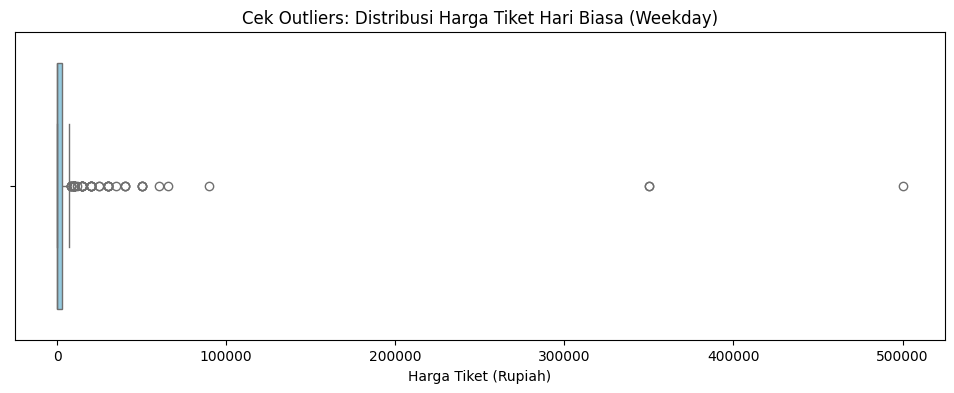

In [4]:
# Visualisasi deteksi outlier pada harga tiket hari biasa (weekday)
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['htm_weekday'], color='skyblue')
plt.title("Cek Outliers: Distribusi Harga Tiket Hari Biasa (Weekday)", fontsize=12)
plt.xlabel("Harga Tiket (Rupiah)", fontsize=10)
plt.savefig('../assets/boxplot_outlier_harga_pariwisata.png', dpi=300, bbox_inches='tight')
plt.show()

df.to_csv('../dataset/clean/data_wisata_clean.csv', index=False);

# BAB 2: EKSPLORASI & PEMBERSIHAN DATA HOTEL

Pada tahap ini, kita akan memproses dataset pendukung yaitu data perhotelan (`data-hotel.csv`). Data ini nantinya akan berfungsi sebagai referensi spasial untuk menghitung **Kriteria C5 (Jumlah Hotel Terdekat)** dari masing-masing objek wisata. Langkah pertama yang dilakukan adalah memuat data dan melihat kondisi aslinya.


In [5]:
## 2.1 Pemuatan Data Hotel (EDA)
# Memuat data mentah hotel
df_hotel_raw = pd.read_csv('../dataset/raw/data-hotel.csv')

print(f"Dimensi Awal Dataset Hotel: {df_hotel_raw.shape} (Baris, Kolom)")
print("\n--- 5 Baris Pertama Data Mentah Hotel ---")
display(df_hotel_raw.head())

print("\n--- Informasi Struktur & Data Kosong Awal ---")
df_hotel_raw.info()

Dimensi Awal Dataset Hotel: (997, 26) (Baris, Kolom)

--- 5 Baris Pertama Data Mentah Hotel ---


,NO,NAMA PENGINAPAN,BINTANG/NON BINTANG,GOLONGAN,JUMLAH KAMAR,ALAMAT,Latitude,Longitude,X,Y,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,1.0,105 Losmen,Non Bintang,Melati,15.0,Sosrowijayan Wetan GT I/105,-7.790382,110.36593,430089.3909,9138823.194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,51 Losmen,Non Bintang,Melati,2.0,Sosrowijayan Wetan Gt I/51 RT 013 RW 02,-7.790211,110.36412,429889.7894,9138841.799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,Abadi Hotel Malioboro,Bintang,Bintang Tiga,85.0,Jl. Pasar Kembang No. 49,-7.790189,110.36325,429793.8584,9138844.087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,Abrakadabra ART B&B,Non Bintang,Akomodasi Lain,6.0,Minggiran Baru No. 19,-7.820833,110.36107,429558.6196,9135455.810,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,Adaro Homestay,Non Bintang,Vila,2.0,Demakan Baru TR III/765,-7.790391,110.35188,428540.2192,9138819.849,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Informasi Struktur & Data Kosong Awal ---
<class 'pandas.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NO                   717 non-null    float64
 1   NAMA PENGINAPAN      717 non-null    str    
 2   BINTANG/NON BINTANG  717 non-null    str    
 3   GOLONGAN             717 non-null    str    
 4   JUMLAH KAMAR         715 non-null    float64
 5   ALAMAT               716 non-null    str    
 6   Latitude             551 non-null    float64
 7   Longitude            551 non-null    float64
 8   X                    398 non-null    float64
 9   Y                    398 non-null    float64
 10  Unnamed: 10          0 non-null      float64
 11  Unnamed: 11          0 non-null      float64
 12  Unnamed: 12          0 non-null      float64
 13  Unnamed: 13          0 non-null      float64
 14  Unnamed: 14          0 non-null      float64
 15  Unna

## 2.2 Pembersihan Data Hotel (Data Cleaning)

Berdasarkan eksplorasi awal, terdapat beberapa "penyakit" pada dataset hotel yang harus dibersihkan agar dapat diproses oleh algoritma Haversine:
1. **Menghapus baris kosong:** Mengeliminasi ratusan baris kosong di bagian bawah dataset (difilter dari kolom `NAMA PENGINAPAN`).
2. **Menghapus kolom tak relevan:** Membuang kolom `NO`, `X`, `Y`, serta belasan kolom *error* yang sepenuhnya kosong (`Unnamed: 10` hingga `Unnamed: 25`).
3. **Krusial - Menghapus tanpa koordinat:** Mengeliminasi hotel yang tidak memiliki data `Latitude` & `Longitude`. Hotel tanpa GPS tidak dapat dihitung jarak radiusnya, sehingga tidak valid untuk analisis spasial.
4. **Standarisasi teks:** Menyeragamkan penulisan pada kolom `GOLONGAN` menjadi format *Title Case* untuk menghindari duplikasi akibat perbedaan huruf kapital.
5. **Imputasi Data:** Mengisi data kosong pada `JUMLAH KAMAR` menggunakan nilai rata-rata tengah (*median*) agar lebih representatif, dan mengisi `ALAMAT` yang kosong dengan teks *default*.

In [6]:
print("--- MEMULAI PEMBERSIHAN DATA HOTEL ---")
# Buat salinan data agar data mentah aslinya tetap aman
df_hotel = df_hotel_raw.copy()

# 1. Hapus baris kosong pada kolom 'NAMA PENGINAPAN' 
df_hotel = df_hotel.dropna(subset=['NAMA PENGINAPAN'])

# 2. Hapus kolom sampah ('NO', 'X', 'Y', dan semua kolom 'Unnamed')
kolom_sampah = ['NO', 'X', 'Y']
kolom_unnamed = [col for col in df_hotel.columns if 'Unnamed' in col]
df_hotel = df_hotel.drop(columns=kolom_sampah + kolom_unnamed, errors='ignore')

# 3. Hapus hotel yang tidak memiliki koordinat 
df_hotel = df_hotel.dropna(subset=['Latitude', 'Longitude'])

# 4. Hapus Duplikat Hotel (Berdasarkan Nama & Koordinat yang sama persis)
jumlah_duplikat_hotel = df_hotel.duplicated(subset=['NAMA PENGINAPAN', 'Latitude', 'Longitude']).sum()
print(f"Ditemukan dan dihapus {jumlah_duplikat_hotel} baris hotel duplikat.")
df_hotel = df_hotel.drop_duplicates(subset=['NAMA PENGINAPAN', 'Latitude', 'Longitude'])

# 5. Sanity Check Koordinat (Pastikan ada di sekitar Pulau Jawa/Jogja)
df_hotel = df_hotel[df_hotel['Latitude'] < 0]

# 6. Standarisasi teks kolom GOLONGAN
if 'GOLONGAN' in df_hotel.columns:
    df_hotel['GOLONGAN'] = df_hotel['GOLONGAN'].astype(str).str.title().str.strip()

# 7. Menangani Missing Values di kolom pendukung
median_kamar = df_hotel['JUMLAH KAMAR'].median()
df_hotel['JUMLAH KAMAR'] = df_hotel['JUMLAH KAMAR'].fillna(median_kamar)
df_hotel['ALAMAT'] = df_hotel['ALAMAT'].fillna('Alamat tidak tertera')

print(f"Ukuran akhir data hotel: {df_hotel.shape} (Baris, Kolom)\n")

print("--- Pengecekan Akhir Missing Values ---")
print(df_hotel.isnull().sum())

print("\n--- Data Hotel Final ---")
display(df_hotel.head())

--- MEMULAI PEMBERSIHAN DATA HOTEL ---
Ditemukan dan dihapus 0 baris hotel duplikat.
Ukuran akhir data hotel: (551, 7) (Baris, Kolom)

--- Pengecekan Akhir Missing Values ---
NAMA PENGINAPAN        0
BINTANG/NON BINTANG    0
GOLONGAN               0
JUMLAH KAMAR           0
ALAMAT                 0
Latitude               0
Longitude              0
dtype: int64

--- Data Hotel Final ---


,NAMA PENGINAPAN,BINTANG/NON BINTANG,GOLONGAN,JUMLAH KAMAR,ALAMAT,Latitude,Longitude
0,105 Losmen,Non Bintang,Melati,15.0,Sosrowijayan Wetan GT I/105,-7.790382,110.36593
1,51 Losmen,Non Bintang,Melati,2.0,Sosrowijayan Wetan Gt I/51 RT 013 RW 02,-7.790211,110.36412
2,Abadi Hotel Malioboro,Bintang,Bintang Tiga,85.0,Jl. Pasar Kembang No. 49,-7.790189,110.36325
3,Abrakadabra ART B&B,Non Bintang,Akomodasi Lain,6.0,Minggiran Baru No. 19,-7.820833,110.36107
4,Adaro Homestay,Non Bintang,Vila,2.0,Demakan Baru TR III/765,-7.790391,110.35188


# BAB 3: FEATURE ENGINEERING (ANALISIS SPASIAL & PENGGABUNGAN DATA)

Pada bab ini, kita melakukan ekstraksi fitur (*Feature Engineering*) berbasis geospasial menggunakan formula **Haversine** . Terdapat dua kriteria baru yang akan dibentuk untuk melengkapi parameter *Weighted Product*:
1. **Jarak Pusat (Kriteria Cost):** Menghitung jarak absolut dari setiap objek wisata ke pusat kota (Tugu Jogja). Semakin dekat jaraknya, bobotnya akan semakin baik.
2. **Jumlah Hotel (Kriteria Benefit / C5):** Menghitung seberapa banyak infrastruktur penginapan yang tersedia dalam radius 2 KM dari titik objek wisata. Penggabungan komputasi dilakukan dengan membandingkan koordinat objek wisata terhadap ratusan titik koordinat hotel yang telah dibersihkan di Bab 2.

In [7]:
import numpy as np


# 1. Menghitung Jarak ke Pusat Kota (Tugu Jogja)
def hitung_jarak_pusat(lat, lon):
    lat_pusat, lon_pusat = -7.7829, 110.3671 # Titik 0 KM / Tugu Jogja
    lat1, lon1, lat2, lon2 = map(np.radians, [lat, lon, lat_pusat, lon_pusat])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # Radius bumi dalam kilometer
    
    return round(c * r, 2)

# Eksekusi fungsi ke dataframe pariwisata
df['jarak_pusat_km'] = df.apply(lambda row: hitung_jarak_pusat(row['latitude'], row['longitude']), axis=1)

# 2. Menghitung Kriteria C5 (Jumlah Hotel Terdekat Radius 2 KM)
def hitung_hotel_radius_3km(lat_w, lon_w, df_h):
    lat_w_rad, lon_w_rad = np.radians(lat_w), np.radians(lon_w)
    lat_h_rad = np.radians(df_h['Latitude'].values)
    lon_h_rad = np.radians(df_h['Longitude'].values)
    
    dlat = lat_h_rad - lat_w_rad
    dlon = lon_h_rad - lon_w_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat_w_rad) * np.cos(lat_h_rad) * np.sin(dlon/2)**2
    jarak_array = (2 * np.arcsin(np.sqrt(a))) * 6371
    
    # Menghitung akumulasi hotel yang masuk dalam jarak <= 3 KM
    return np.sum(jarak_array <= 3.0)

# Eksekusi fungsi penggabungan
df['jumlah_hotel_terdekat'] = df.apply(
    lambda row: hitung_hotel_radius_3km(row['latitude'], row['longitude'], df_hotel), axis=1
)


# Menampilkan cuplikan hasil akhir perhitungan
print("\n--- CUPLIKAN HASIL EKSTRAKSI FITUR SPASIAL ---")
display(df[['nama', 'jarak_pusat_km', 'jumlah_hotel_terdekat']].head())


--- CUPLIKAN HASIL EKSTRAKSI FITUR SPASIAL ---


,nama,jarak_pusat_km,jumlah_hotel_terdekat
0,Candi Borobudur,26.58,0
1,Candi Prambanan,14.14,0
2,Tebing Breksi,15.15,0
3,Gembira Loka Zoo,4.18,119
4,The Palace of Yogyakarta (Keraton Yogyakarta),2.51,492


# BAB 4: FINALISASI SPK & EKSPOR DATA

Tahap terakhir dari pemrosesan data adalah mempersiapkan *dataset* agar dapat diproses dengan algoritma *Weighted Product* (WP) di aplikasi utama. Karena metode WP menggunakan operasi perkalian (*product*), **nilai 0 tidak boleh ada** di dalam perhitungan karena akan merusak seluruh kalkulasi. Oleh karena itu, kita mengubah angka `0` menjadi `0.01` sebagai nilai toleransi matematis.

In [8]:
kolom_anti_nol = ['htm_weekday', 'htm_weekend', 'jarak_pusat_km', 'jumlah_hotel_terdekat']

for col in kolom_anti_nol:
    df[col] = df[col].replace(0, 0.01)


kolom_final = [
    'nama', 'type', 'latitude', 'longitude', 
    'htm_weekday', 'htm_weekend', 'jarak_pusat_km', 'vote_average', 'vote_count', 'jumlah_hotel_terdekat'
]

df_final = df[kolom_final]

# B. Ekspor Data Hotel Bersih
file_hotel = '../dataset/clean/data_hotel_clean.csv'
df_hotel.to_csv(file_hotel, index=False)

# B. Ekspor Data Pariwisata Bersih
file_pariwisata = '../dataset/clean/data_pariwisata_clean.csv'
df_final.to_csv(file_pariwisata, index=False)

print("\n--- BENTUK DATA FINAL ---")
display(df_final.head(10))


--- BENTUK DATA FINAL ---


,nama,type,latitude,longitude,htm_weekday,htm_weekend,jarak_pusat_km,vote_average,vote_count,jumlah_hotel_terdekat
0,Candi Borobudur,Budaya dan Sejarah,-7.607087,110.203623,50000.0,50000.0,26.58,4.7,81922,0.01
1,Candi Prambanan,Budaya dan Sejarah,-7.751835,110.491532,50000.0,50000.0,14.14,4.7,71751,0.01
2,Tebing Breksi,Alam,-7.781477,110.504576,10000.0,10000.0,15.15,4.4,51431,0.01
3,Gembira Loka Zoo,Buatan,-7.806234,110.396798,20000.0,25000.0,4.18,4.5,36337,119.00
4,The Palace of Yogyakarta (Keraton Yogyakarta),Budaya dan Sejarah,-7.805284,110.364203,8000.0,8000.0,2.51,4.6,30091,492.00
5,Taman Sari,Budaya dan Sejarah,-7.809833,110.359512,5000.0,5000.0,3.11,4.6,27899,459.00
6,Hutan Pinus Mangunan Dlingo,Alam,-7.926784,110.431997,3000.0,3000.0,17.52,4.6,18271,0.01
7,Jogja Bay,Wisata Air,-7.747846,110.418875,90000.0,100000.0,6.91,4.4,16877,0.01
8,The World Landmarks - Merapi Park Yogyakarta,Buatan,-7.620905,110.421627,15000.0,15000.0,18.99,4.2,16201,0.01
9,The Lost World Castle,Buatan,-7.604165,110.451004,30000.0,30000.0,21.92,4.3,16110,0.01
